# Lead Scoring EDA
Univariate + bivariate analysis of fit score, priority score, remark tier, company size, and revenue.

In [33]:
import warnings, os
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

OUT = "eda_plots"
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.edgecolor':   '#D3D1C7',
    'axes.grid':        True,
    'grid.color':       '#F1EFE8',
    'grid.linewidth':   0.8,
    'font.size':        11,
    'axes.titlesize':   12,
    'axes.titleweight': '500',
    'axes.labelsize':   10,
    'axes.labelcolor':  '#444441',
    'xtick.color':      '#888780',
    'ytick.color':      '#888780',
})

PALETTE = {
    'Good':     '#3B6D11',
    'Bad':      '#BA7517',
    'Not Ugly': '#D85A30',
    'Ugly':     '#A32D2D',
}
REMARK_ORDER = ['Good', 'Bad', 'Not Ugly', 'Ugly']

def save(name):
    path = f"{OUT}/{name}.png"
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    plt.close()
    print(f"saved → {path}")

## 1. Load & clean

In [34]:
df = pd.read_csv('/media/prince/5A4E832F4E83034D/Rocketsteer/REST_API/test/visualization/Wamly - Warmly RES.csv')

# drop cols with no analytical value
DROP = ['score_explanation', 'Full Name', 'First Name', 'Last Name',
        'Email', 'LinkedIn', 'Domain', 'Country', 'timing_score']
df.drop(columns=[c for c in DROP if c in df.columns], inplace=True)

# ordinal encode employee count
EMP_ORDER = ['<50','51-250','251-1K','1K-5K','5K-10K','10K-50K','50K-100K','100K+']
REV_ORDER = ['<$1M','$1M-$10M','$10M-$100M','$100M-$250M','$250M-$500M',
             '$500M-$1B','$1B-$10B','$10B+']

df['# Employees'] = pd.Categorical(df['# Employees'], categories=EMP_ORDER, ordered=True)
df['Annual Revenue'] = pd.Categorical(df['Annual Revenue'], categories=REV_ORDER, ordered=True)
df['Remark'] = pd.Categorical(df['Remark'], categories=REMARK_ORDER, ordered=True)

print(df.shape)
df.head()

(428, 7)


,Remark,fit_score,priority_score,Company,Job Title,# Employees,Annual Revenue
0,Good,100,59,Saudi Automotive Services Company (SASCO),Group Information Technology Director,251-1K,$100M-$250M
1,Good,100,59,Network International,Chief Digital Officer,1K-5K,$500M-$1B
2,Good,100,59,AL Nabooda Automobiles LLC.,Chief Digital Officer (CDO),1K-5K,$250M-$500M
3,Good,100,59,Ministry of Health Saudi Arabia,IT Director,10K-50K,$1B-$10B
4,Good,100,59,Ministry of Health Saudi Arabia,Director of IT,10K-50K,$1B-$10B


## 2. Univariate plots

In [35]:
def plot_score_hist(col, color='#534AB7', binwidth=5):
    """Histogram + KDE for any numeric score column."""
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.histplot(df[col], binwidth=binwidth, color=color, alpha=0.75,
                 edgecolor='white', linewidth=0.6, ax=ax)
    ax.axvline(df[col].mean(), color=color, linewidth=1.8,
               linestyle='--', label=f'mean {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='#888780', linewidth=1.4,
               linestyle=':', label=f'median {df[col].median():.1f}')
    ax.set_xlabel(col); ax.set_ylabel('Count')
    ax.set_title(f'Distribution of {col}')
    ax.legend(frameon=False, fontsize=9)
    save(col)

In [36]:
def plot_cat_bar(col, palette=None, order=None):
    """Horizontal count bar for any categorical column."""
    counts = df[col].value_counts()
    if order:
        counts = counts.reindex([o for o in order if o in counts.index])
    colors = [palette.get(k, '#888780') for k in counts.index] if palette else '#534AB7'
    fig, ax = plt.subplots(figsize=(7, max(3, len(counts) * 0.55)))
    bars = ax.barh(counts.index.astype(str), counts.values,
                   color=colors, edgecolor='white', linewidth=0.5, height=0.6)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
                str(v), va='center', fontsize=9, color='#444441')
    ax.set_xlabel('Count'); ax.set_title(f'{col} — counts')
    ax.invert_yaxis()
    save(col.replace(' ', '_').replace('#', 'num'))

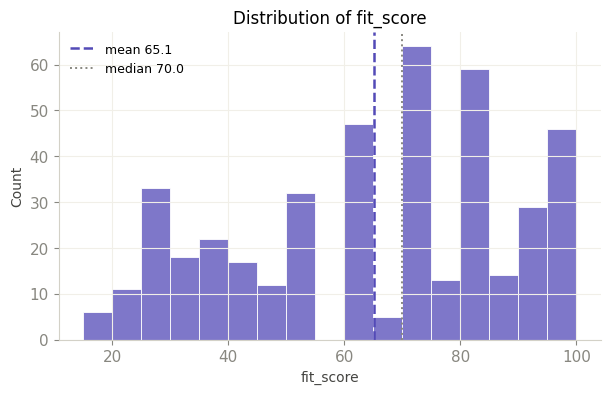

saved → eda_plots/fit_score.png


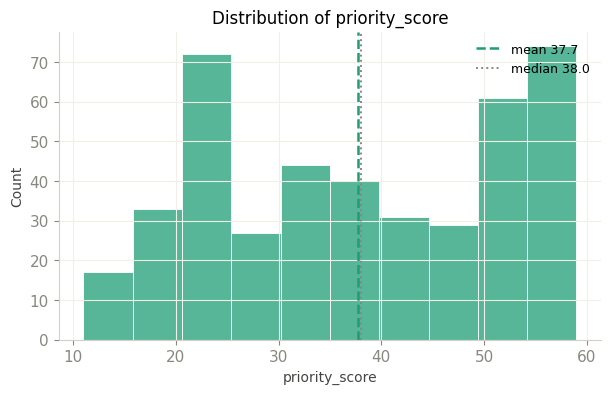

saved → eda_plots/priority_score.png


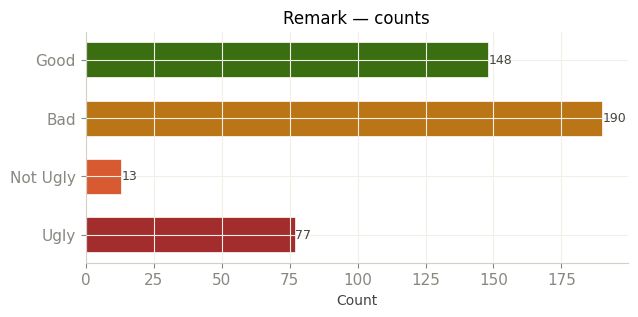

saved → eda_plots/Remark.png


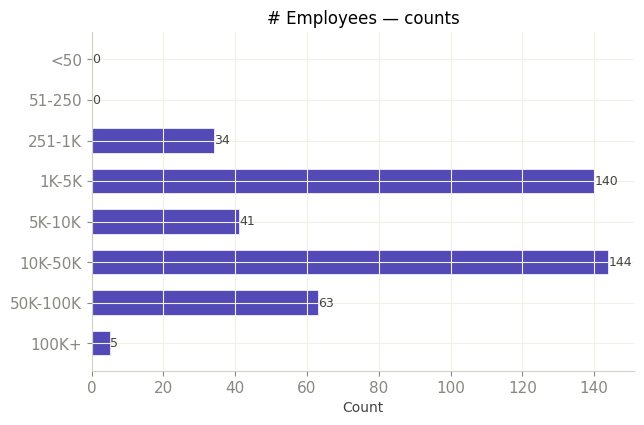

saved → eda_plots/num_Employees.png


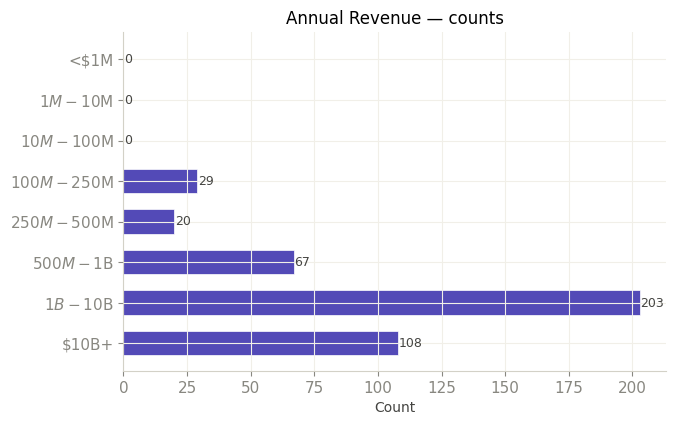

saved → eda_plots/Annual_Revenue.png


In [37]:
# call univariate
plot_score_hist('fit_score',      color='#534AB7')
plot_score_hist('priority_score', color='#1D9E75')
plot_cat_bar('Remark',         palette=PALETTE, order=REMARK_ORDER)
plot_cat_bar('# Employees',    order=EMP_ORDER)
plot_cat_bar('Annual Revenue', order=REV_ORDER)

## 3. Bivariate plots

In [38]:
def plot_box_strip(x_col, y_col='fit_score', order=None, palette=None):
    """Box + jitter strip for score vs categorical."""
    pal = palette or sns.color_palette('muted', df[x_col].nunique())
    ord_ = order or df[x_col].cat.categories.tolist() if hasattr(df[x_col], 'cat') else None
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.boxplot(data=df, x=x_col, y=y_col, order=ord_, palette=pal,
                width=0.45, fliersize=0, linewidth=1.2,
                boxprops=dict(alpha=0.35), ax=ax)
    sns.stripplot(data=df, x=x_col, y=y_col, order=ord_, palette=pal,
                  size=7, jitter=0.15, alpha=0.85, edgecolor='white',
                  linewidth=0.6, ax=ax)
    # mean markers
    means = df.groupby(x_col, observed=True)[y_col].mean()
    for i, cat in enumerate(ord_ or means.index):
        if cat in means:
            ax.hlines(means[cat], i - 0.3, i + 0.3,
                      colors='#2C2C2A', linewidth=2, zorder=5)
    ax.set_xlabel(''); ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} by {x_col}')
    plt.xticks(rotation=15, ha='right')
    save(f'{x_col.replace(" ","_").replace("#","num")}__vs__{y_col}')

In [39]:
def plot_scatter(x_col, y_col, hue_col='Remark', palette=None):
    """Scatter with hue, regression line optional."""
    pal = palette or PALETTE
    fig, ax = plt.subplots(figsize=(7, 5))
    for remark in REMARK_ORDER:
        sub = df[df['Remark'] == remark]
        ax.scatter(sub[x_col], sub[y_col], color=pal.get(remark, '#888'),
                   s=80, alpha=0.85, edgecolors='white', linewidth=0.7,
                   label=remark, zorder=3)
    # regression line (all data)
    m, b = np.polyfit(df[x_col], df[y_col], 1)
    xs = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(xs, m*xs + b, color='#888780', linewidth=1.2,
            linestyle='--', label='trend', zorder=2)
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    ax.set_title(f'{x_col} vs {y_col}')
    ax.legend(frameon=False, fontsize=9)
    save(f'{x_col}__vs__{y_col}')

In [40]:
def plot_heatmap_mean(x_col, y_col, value_col='fit_score'):
    """Mean value heatmap for two categoricals."""
    pivot = df.pivot_table(index=y_col, columns=x_col,
                           values=value_col, aggfunc='mean', observed=True)
    fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1]*1.1),
                                    max(3, pivot.shape[0]*0.7)))
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn',
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': f'mean {value_col}', 'shrink': 0.7}, ax=ax)
    ax.set_title(f'Mean {value_col}: {x_col} × {y_col}')
    ax.set_xlabel(x_col); ax.set_ylabel(y_col)
    plt.xticks(rotation=30, ha='right')
    save(f'{x_col.replace(" ","_").replace("#","num")}__x__{y_col.replace(" ","_").replace("#","num")}_heatmap')

In [41]:
def plot_violin(x_col, y_col='fit_score', order=None, palette=None):
    """Violin plot for score distribution per category."""
    pal  = palette or sns.color_palette('muted', df[x_col].nunique())
    ord_ = order or (df[x_col].cat.categories.tolist()
                     if hasattr(df[x_col], 'cat') else None)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    sns.violinplot(data=df, x=x_col, y=y_col, order=ord_, palette=pal,
                   inner='box', cut=0, linewidth=1, ax=ax)
    ax.set_xlabel(''); ax.set_ylabel(y_col)
    ax.set_title(f'{y_col} distribution — {x_col}')
    plt.xticks(rotation=15, ha='right')
    save(f'{x_col.replace(" ","_").replace("#","num")}__violin__{y_col}')

In [42]:
def plot_grouped_bar_mean(x_col, group_col='Remark', value_col='fit_score',
                          order=None, palette=None):
    """Grouped bar of mean score: x_col groups, hue = group_col."""
    pal  = palette or PALETTE
    ord_ = order or (df[x_col].cat.categories.tolist()
                     if hasattr(df[x_col], 'cat') else None)
    grp  = df.groupby([x_col, group_col], observed=True)[value_col].mean().reset_index()
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.barplot(data=grp, x=x_col, y=value_col, hue=group_col,
                order=ord_, hue_order=REMARK_ORDER, palette=pal,
                edgecolor='white', linewidth=0.5, ax=ax)
    ax.set_xlabel(x_col); ax.set_ylabel(f'mean {value_col}')
    ax.set_title(f'Mean {value_col} by {x_col} and {group_col}')
    ax.legend(frameon=False, fontsize=9, title=group_col)
    plt.xticks(rotation=20, ha='right')
    save(f'{x_col.replace(" ","_").replace("#","num")}__grouped_bar__{value_col}')

## 4. Run bivariate plots

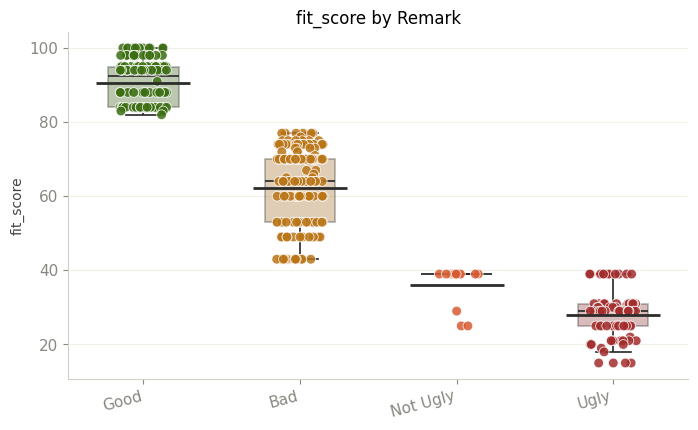

saved → eda_plots/Remark__vs__fit_score.png


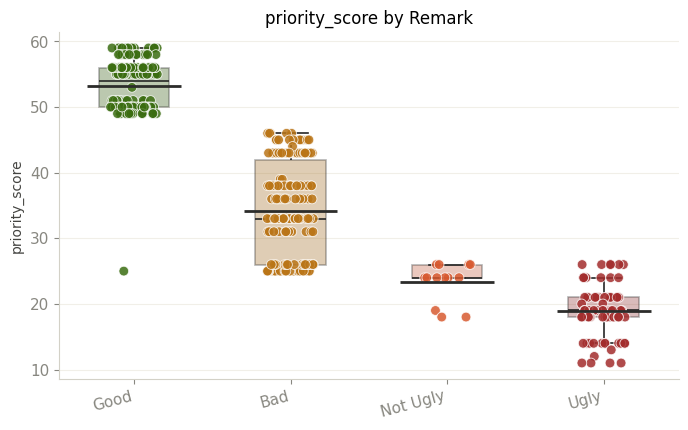

saved → eda_plots/Remark__vs__priority_score.png


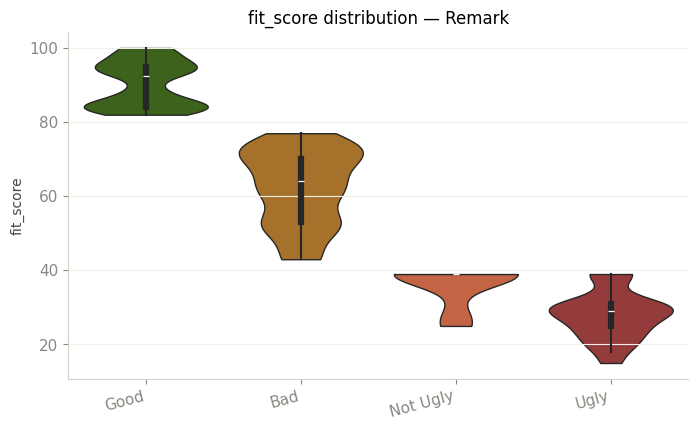

saved → eda_plots/Remark__violin__fit_score.png


In [43]:
# score vs remark
plot_box_strip('Remark', 'fit_score',      order=REMARK_ORDER, palette=list(PALETTE.values()))
plot_box_strip('Remark', 'priority_score', order=REMARK_ORDER, palette=list(PALETTE.values()))
plot_violin('Remark', 'fit_score',         order=REMARK_ORDER, palette=list(PALETTE.values()))

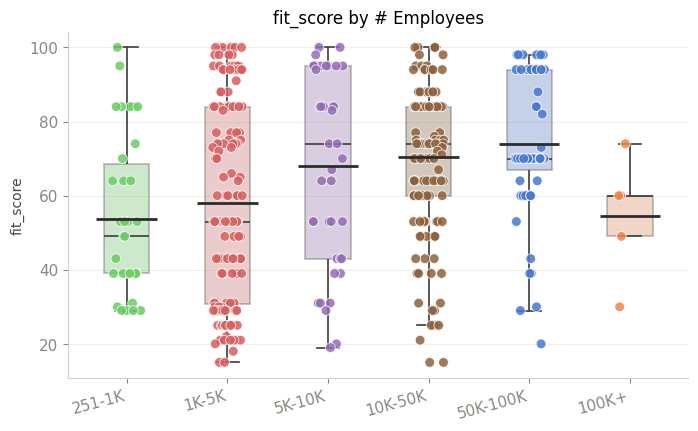

saved → eda_plots/num_Employees__vs__fit_score.png


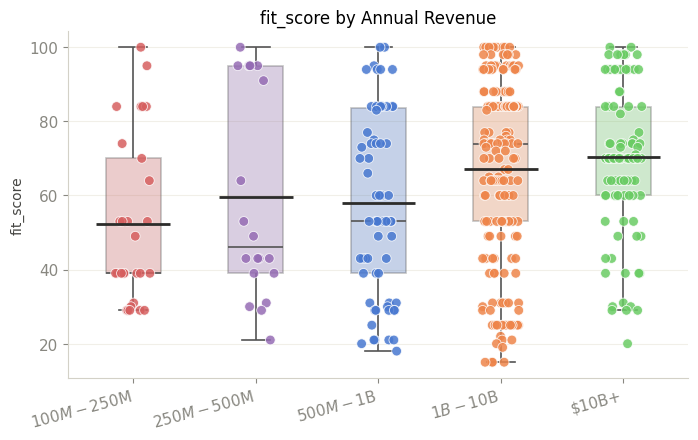

saved → eda_plots/Annual_Revenue__vs__fit_score.png


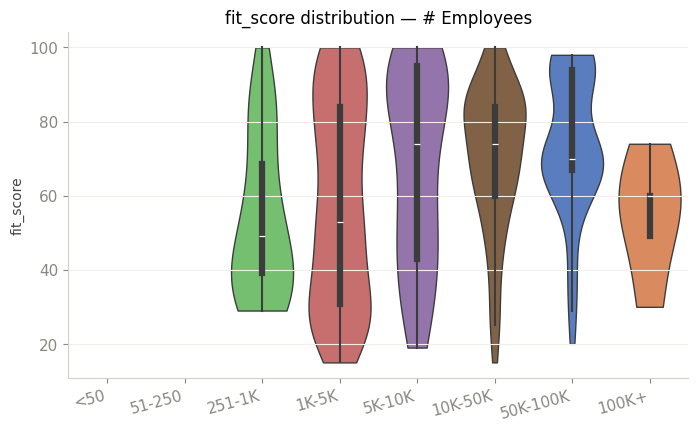

saved → eda_plots/num_Employees__violin__fit_score.png


In [44]:
# score vs company size / revenue
plot_box_strip('# Employees',    'fit_score', order=EMP_ORDER)
plot_box_strip('Annual Revenue', 'fit_score', order=REV_ORDER)
plot_violin('# Employees',    'fit_score', order=EMP_ORDER)

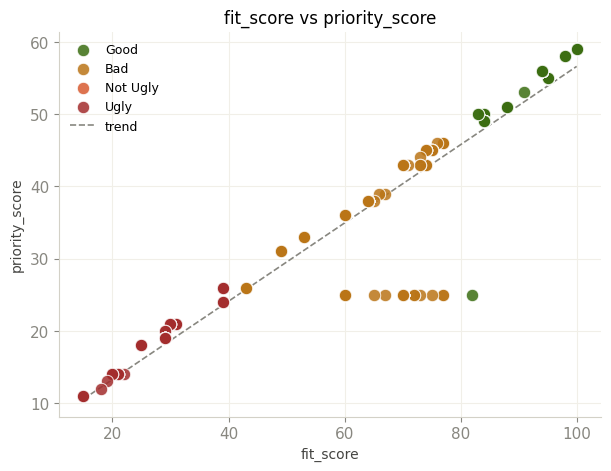

saved → eda_plots/fit_score__vs__priority_score.png


In [45]:
# numeric vs numeric
plot_scatter('fit_score', 'priority_score')

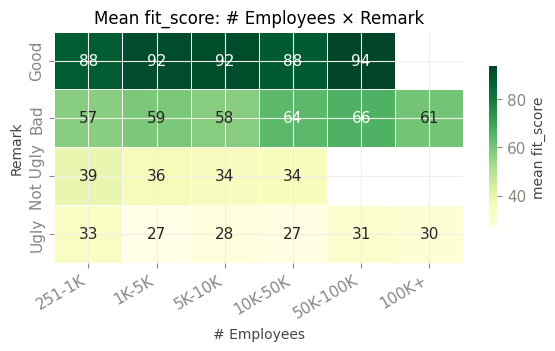

saved → eda_plots/num_Employees__x__Remark_heatmap.png


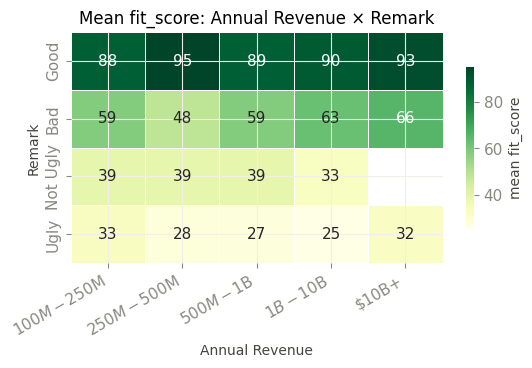

saved → eda_plots/Annual_Revenue__x__Remark_heatmap.png


In [46]:
# heatmaps
plot_heatmap_mean('# Employees',    'Remark',  'fit_score')
plot_heatmap_mean('Annual Revenue', 'Remark',  'fit_score')

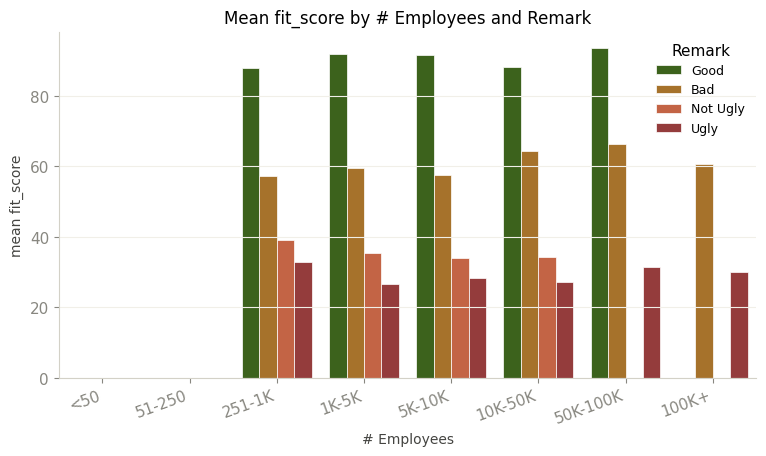

saved → eda_plots/num_Employees__grouped_bar__fit_score.png


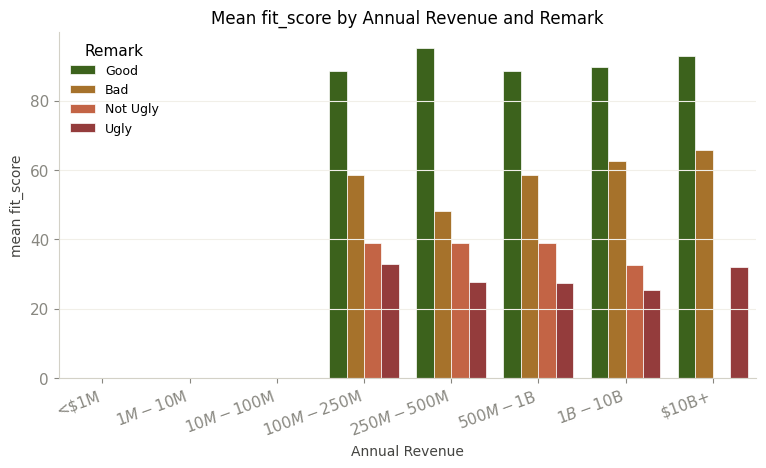

saved → eda_plots/Annual_Revenue__grouped_bar__fit_score.png


In [47]:
# grouped bar
plot_grouped_bar_mean('# Employees',    group_col='Remark', value_col='fit_score', order=EMP_ORDER)
plot_grouped_bar_mean('Annual Revenue', group_col='Remark', value_col='fit_score', order=REV_ORDER)

## 5. Quick summary table

In [48]:
summary = df.groupby('Remark', observed=True).agg(
    count=('fit_score','count'),
    fit_mean=('fit_score','mean'),
    fit_std=('fit_score','std'),
    fit_min=('fit_score','min'),
    fit_max=('fit_score','max'),
    priority_mean=('priority_score','mean'),
).round(1)
summary

,count,fit_mean,fit_std,fit_min,fit_max,priority_mean
Remark,,,,,,
Good,148,90.5,6.1,82,100,53.2
Bad,190,62.3,10.3,43,77,34.2
Not Ugly,13,36.1,5.6,25,39,23.3
Ugly,77,28.1,6.4,15,39,18.9
